# 📊 Giai đoạn 1: Khám phá dữ liệu & Trích xuất đặc trưng

Phần bàn giao của **TV2 – Feature Engineering & EDA**. Notebook sử dụng dữ liệu sạch do TV1 bàn giao, xuất biểu đồ vào `reports/figures/`, và tạo bộ đặc trưng cho TV3.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'reviews_cleaned.xlsx'
FIGURES_DIR = PROJECT_ROOT / 'reports' / 'figures'
MODELS_DIR = PROJECT_ROOT / 'models'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

sns.set_theme(style='whitegrid', context='notebook')
df = pd.read_excel(DATA_PATH)
required_columns = {'Rating', 'sentiment', 'clean_advance_text'}
missing = required_columns.difference(df.columns)
if missing:
    raise ValueError(f'Thiếu cột bắt buộc: {sorted(missing)}')
print(f'Dữ liệu: {df.shape[0]:,} mẫu, {df.shape[1]} cột')
display(df.head(3))

Dữ liệu: 8,417 mẫu, 23 cột


,id,Company Name,Cmt_day,Title,What I liked,Suggestions for improvement,Rating,Salary & benefits,Training & learning,Management cares about me,...,raw_review_text,clean_basic_text,pos_w,neg_w,pos_e,neg_e,total_we,sentiment_ratio,clean_advance_text,sentiment
0,4,Accenture,March 2025,"Môi trường thoải mái, ít áp lực, có thể làm vi...","Môi trường thoải mái, ít áp lực, có thể làm vi...",Cần đánh giá KPI khách quan và phân chia công ...,4,4,4,4,...,"Môi trường thoải mái, ít áp lực, có thể làm vi...",môi trường thoải mái ít áp lực có thể làm việc...,4,3,0,0,7,0.1429,môi_trường thoải_mái áp_lực làm_việc hybrid lư...,Positive
1,4,Accenture,January 2025,Công ty trẻ trung năng động,"Cơ sở vật chất đẹp, công ty trẻ trung năng độn...",Nên nghiên cứu lại range lương của thì trường....,4,3,4,4,...,Công ty trẻ trung năng động . Cơ sở vật chất đ...,công ty trẻ trung năng động cơ sở vật chất đẹp...,4,1,0,0,5,0.6000,công_ty trẻ trung_năng động_cơ_sở_vật_chất đẹp...,Positive
2,4,Accenture,October 2023,Môi trường làm việc thoải mái vui vẻ,"Mội người thân thiện, giúp đỡ lẫn nhau. Chương...",Do công ty làm outsourcing về mảng system nên ...,3,3,3,3,...,Môi trường làm việc thoải mái vui vẻ . Mội ngư...,môi trường làm việc thoải mái vui vẻ mội người...,6,1,0,0,7,0.7143,môi_trường làm_việc thoải_mái vui_vẻ mội thân_...,Neutral


## 1. Kiểm tra chất lượng và cấu trúc dữ liệu

In [2]:
quality = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing': df.isna().sum(),
    'missing_pct': (df.isna().mean() * 100).round(2),
    'unique': df.nunique(dropna=True),
})
display(quality)
print(f'Số dòng trùng hoàn toàn: {df.duplicated().sum():,}')

,dtype,missing,missing_pct,unique
id,int64,0,0.00,180
Company Name,str,0,0.00,180
Cmt_day,str,0,0.00,107
Title,str,0,0.00,6951
What I liked,str,1,0.01,8405
Suggestions for improvement,str,5,0.06,7724
Rating,int64,0,0.00,5
Salary & benefits,int64,0,0.00,5
Training & learning,int64,0,0.00,5
Management cares about me,int64,0,0.00,5


Số dòng trùng hoàn toàn: 0


## 2. Phân bố điểm đánh giá và nhãn cảm xúc

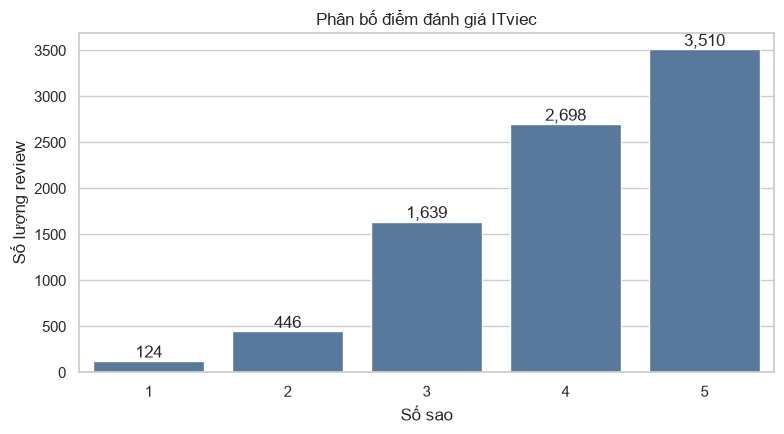

,count
Rating,
1,124
2,446
3,1639
4,2698
5,3510


In [3]:
rating_counts = df['Rating'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(x=rating_counts.index, y=rating_counts.values, color='#4C78A8', ax=ax)
ax.set(title='Phân bố điểm đánh giá ITviec', xlabel='Số sao', ylabel='Số lượng review')
for patch, value in zip(ax.patches, rating_counts.values):
    ax.annotate(f'{value:,}', (patch.get_x() + patch.get_width() / 2, value), ha='center', va='bottom')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'eda_rating_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
display(rating_counts.rename('count').to_frame())

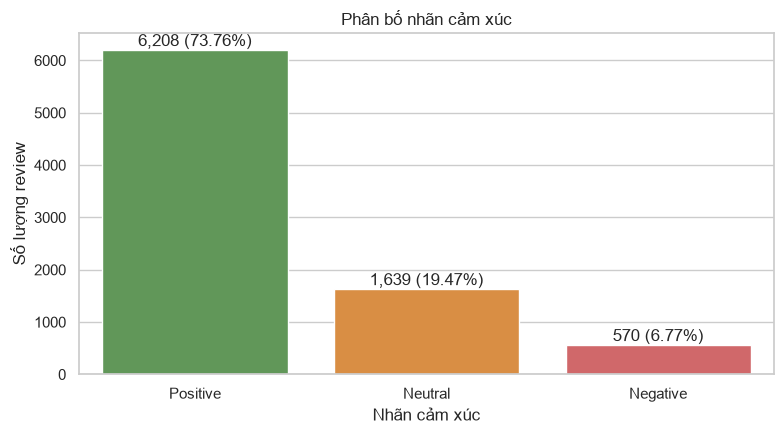

,count,percent
sentiment,,
Positive,6208,73.76
Neutral,1639,19.47
Negative,570,6.77


In [4]:
sentiment_order = ['Positive', 'Neutral', 'Negative']
sentiment_counts = df['sentiment'].value_counts().reindex(sentiment_order)
sentiment_pct = (sentiment_counts / len(df) * 100).round(2)
sentiment_summary = pd.DataFrame({'count': sentiment_counts, 'percent': sentiment_pct})
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ['#59A14F', '#F28E2B', '#E15759']
sns.barplot(x=sentiment_summary.index, y=sentiment_summary['count'], palette=colors, hue=sentiment_summary.index, legend=False, ax=ax)
ax.set(title='Phân bố nhãn cảm xúc', xlabel='Nhãn cảm xúc', ylabel='Số lượng review')
for patch, (count, percent) in zip(ax.patches, sentiment_summary[['count', 'percent']].itertuples(index=False, name=None)):
    ax.annotate(f'{count:,} ({percent:.2f}%)', (patch.get_x() + patch.get_width() / 2, count), ha='center', va='bottom')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'eda_sentiment_counts.png', dpi=300, bbox_inches='tight')
plt.show()
display(sentiment_summary)

## 3. Độ dài phần khen và đề xuất cải thiện

Độ dài được tính theo số token phân tách bằng khoảng trắng. Trục biểu đồ được giới hạn tại phân vị 99 để các ngoại lệ rất dài không che khuất phân bố chính.

,count,mean,std,min,50%,75%,90%,95%,99%,max
What I liked,8417.0,50.29,51.40,0.0,36.0,60.0,96.0,131.0,237.36,1400.0
Suggestions for improvement,8417.0,29.97,37.54,0.0,20.0,32.0,54.0,78.0,184.00,876.0


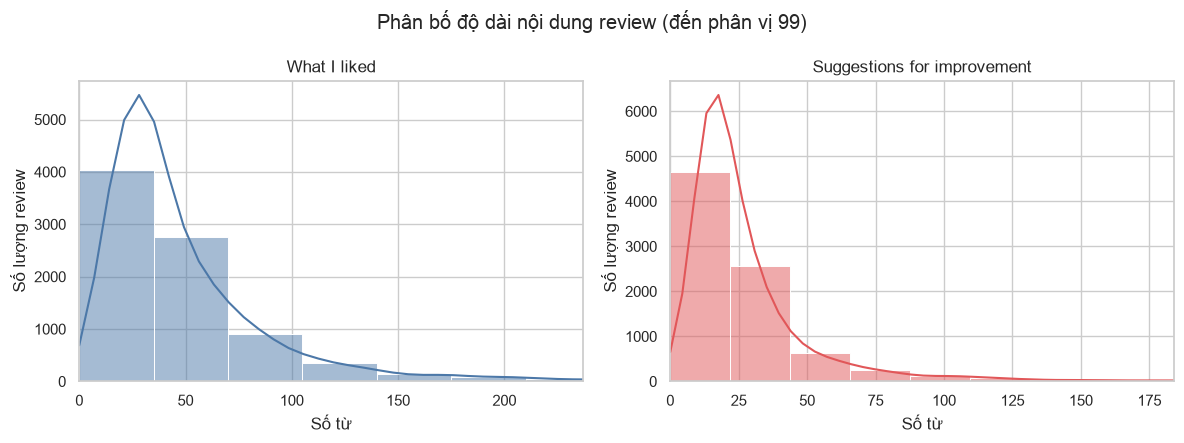

In [5]:
length_columns = ['What I liked', 'Suggestions for improvement']
length_data = pd.DataFrame({column: df[column].fillna('').astype(str).str.split().str.len() for column in length_columns})
length_summary = length_data.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).T.round(2)
display(length_summary)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, column, color in zip(axes, length_columns, ['#4C78A8', '#E15759']):
    upper = max(1, int(length_data[column].quantile(0.99)))
    sns.histplot(length_data[column], bins=40, kde=True, color=color, ax=ax)
    ax.set_xlim(0, upper)
    ax.set(title=column, xlabel='Số từ', ylabel='Số lượng review')
fig.suptitle('Phân bố độ dài nội dung review (đến phân vị 99)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'eda_text_length_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 3b. Thống kê token rỗng và review quá ngắn

Tài liệu rỗng sẽ tạo vector TF-IDF toàn số 0 và trở thành nhiễu khi huấn luyện, nên cần kiểm tra trước khi vector hóa.


In [6]:
from src.features import deduplicate_modeling_rows

modeling_preview, _ = deduplicate_modeling_rows(df)
token_counts = modeling_preview['clean_advance_text'].fillna('').str.split().apply(len)
empty_stats = pd.DataFrame(
    [
        ('Chuỗi rỗng hoàn toàn', int((modeling_preview['clean_advance_text'].fillna('').str.strip() == '').sum())),
        ('Dưới 3 token', int((token_counts < 3).sum())),
        ('Dưới 5 token', int((token_counts < 5).sum())),
        ('Dưới 10 token', int((token_counts < 10).sum())),
    ],
    columns=['Nhóm', 'Số review'],
)
empty_stats['Tỷ lệ %'] = (empty_stats['Số review'] / len(modeling_preview) * 100).round(2)
display(empty_stats)
print(f'Tổng review dùng cho mô hình: {len(modeling_preview)}')
print(f'Số token trung bình: {token_counts.mean():.2f} | trung vị: {token_counts.median():.0f} '
      f'| nhỏ nhất: {token_counts.min()} | lớn nhất: {token_counts.max()}')

,Nhóm,Số review,Tỷ lệ %
0,Chuỗi rỗng hoàn toàn,0,0.00
1,Dưới 3 token,0,0.00
2,Dưới 5 token,0,0.00
3,Dưới 10 token,35,0.42


Tổng review dùng cho mô hình: 8413
Số token trung bình: 35.95 | trung vị: 28 | nhỏ nhất: 5 | lớn nhất: 511


## 4. Điểm khía cạnh và cảm xúc tổng thể

Dùng hệ số Spearman vì các điểm đánh giá là thang thứ bậc 1–5. `Rating` chỉ phục vụ EDA và tạo nhãn; **không** được đưa vào ma trận huấn luyện để tránh rò rỉ nhãn.

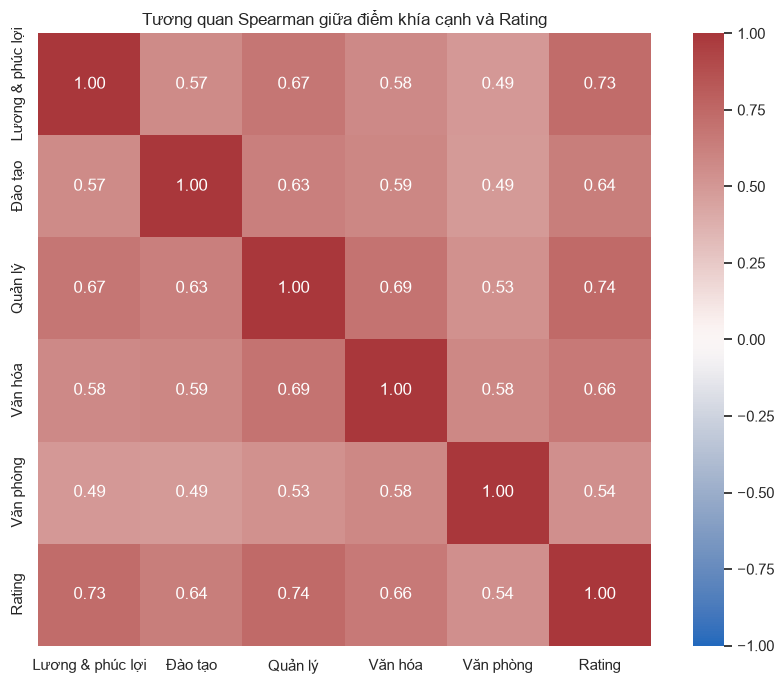

,Salary & benefits,Training & learning,Management cares about me,Culture & fun,Office & workspace
sentiment,,,,,
Positive,4.15,4.30,4.33,4.41,4.34
Neutral,2.72,3.25,2.91,3.36,3.52
Negative,2.08,2.33,1.93,2.38,2.97


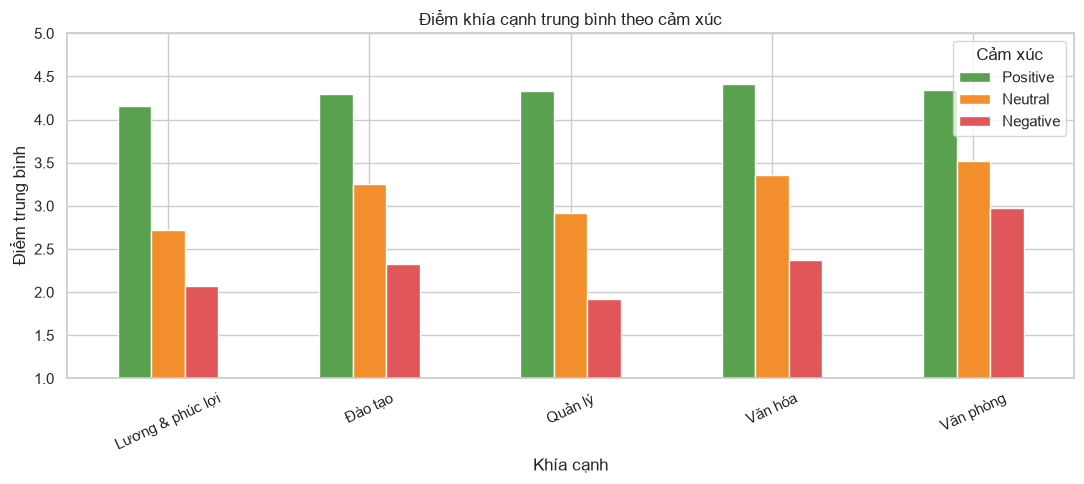

In [7]:
aspect_columns = [
    'Salary & benefits',
    'Training & learning',
    'Management cares about me',
    'Culture & fun',
    'Office & workspace',
]
aspect_labels = {
    'Salary & benefits': 'Lương & phúc lợi',
    'Training & learning': 'Đào tạo',
    'Management cares about me': 'Quản lý',
    'Culture & fun': 'Văn hóa',
    'Office & workspace': 'Văn phòng',
}
correlations = df[aspect_columns + ['Rating']].corr(method='spearman')
correlations_display = correlations.rename(index=aspect_labels, columns=aspect_labels)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(correlations_display, annot=True, fmt='.2f', cmap='vlag', vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title('Tương quan Spearman giữa điểm khía cạnh và Rating')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'eda_aspect_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

aspect_by_sentiment = df.groupby('sentiment')[aspect_columns].mean().reindex(sentiment_order)
display(aspect_by_sentiment.round(2))
fig, ax = plt.subplots(figsize=(11, 5))
aspect_by_sentiment.rename(columns=aspect_labels).T.plot(kind='bar', ax=ax, color=colors)
ax.set(title='Điểm khía cạnh trung bình theo cảm xúc', xlabel='Khía cạnh', ylabel='Điểm trung bình', ylim=(1, 5))
ax.legend(title='Cảm xúc')
ax.tick_params(axis='x', rotation=25)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'eda_aspect_by_sentiment.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Mức tập trung theo công ty và biến động theo thời gian

EDA này cho biết dữ liệu có bị một vài công ty chi phối hay không và phân bố sentiment có thay đổi theo năm hay không.

Số công ty: 180; công ty dưới 20 review: 110


,reviews
Company Name,
FPT Software,2014
NashTech,308
Bosch Global Software Technologies Company Limited,278
VNG Corporation,259
KMS Technology,251
Hitachi Digital Services,249
TymeX,213
Samsung Electronics HCMC CE Complex,184
Orient Software Development Corp.,176


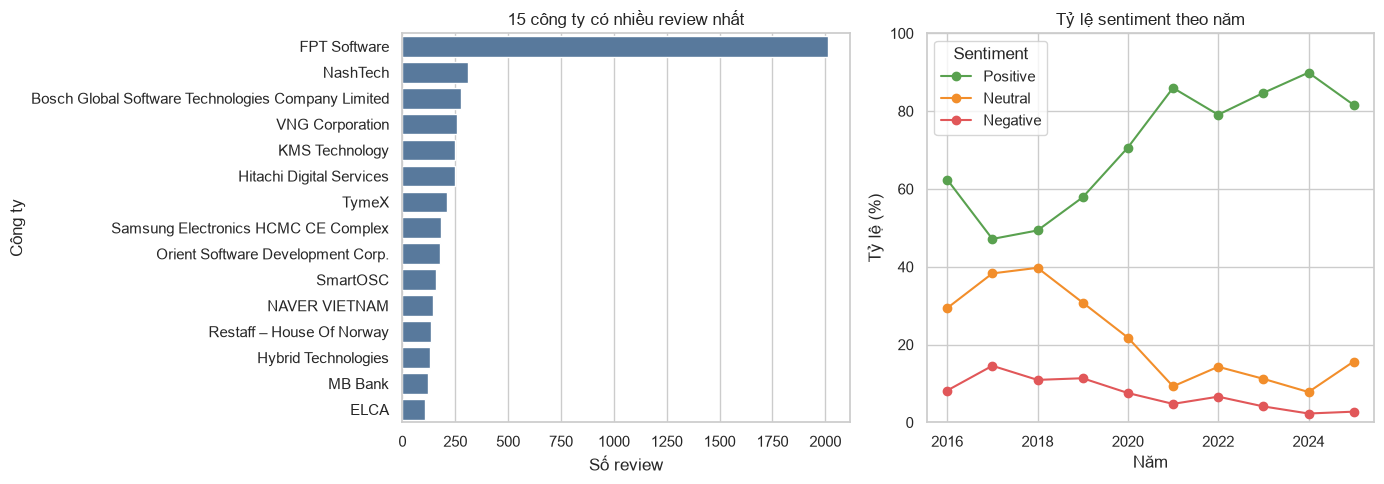

In [8]:
company_counts = df['Company Name'].value_counts()
df['review_date'] = pd.to_datetime(df['Cmt_day'], format='%B %Y', errors='coerce')
df['review_year'] = df['review_date'].dt.year
print(f'Số công ty: {company_counts.size}; công ty dưới 20 review: {(company_counts < 20).sum()}')
display(company_counts.head(15).rename('reviews').to_frame())

year_sentiment = pd.crosstab(df['review_year'], df['sentiment'], normalize='index').reindex(columns=sentiment_order) * 100
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=company_counts.head(15).values, y=company_counts.head(15).index, color='#4C78A8', ax=axes[0])
axes[0].set(title='15 công ty có nhiều review nhất', xlabel='Số review', ylabel='Công ty')
year_sentiment.plot(ax=axes[1], color=colors, marker='o')
axes[1].set(title='Tỷ lệ sentiment theo năm', xlabel='Năm', ylabel='Tỷ lệ (%)', ylim=(0, 100))
axes[1].legend(title='Sentiment')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'eda_company_time_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Chất lượng weak labels và coverage của lexicon

`sentiment` được suy ra từ Rating nên được xem là weak label. `Recommend?`, lexicon coverage và text trùng được dùng như tín hiệu audit, không phải bằng chứng biến weak label thành ground truth.

Lexicon có tín hiệu: 99.54%
Dòng có emoji feature khác 0: 0
Dòng thuộc nhóm text trùng: 6; nhóm text trùng khác nhãn: 1


Recommend?,No,Yes
sentiment,,
Positive,87,6121
Neutral,411,1228
Negative,529,41


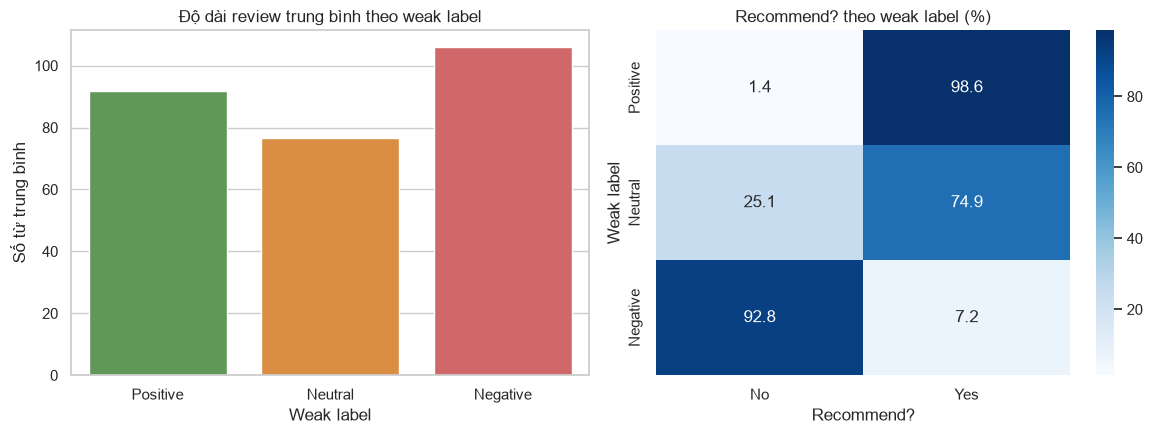

In [9]:
recommend_audit = pd.crosstab(df['sentiment'], df['Recommend?']).reindex(sentiment_order)
lexicon_coverage = (df['total_we'] > 0).mean() * 100
emoji_nonzero = int(((df['pos_e'] > 0) | (df['neg_e'] > 0)).sum())
duplicate_rows = int(df.duplicated('clean_advance_text', keep=False).sum())
conflicting_text_groups = int((df.groupby('clean_advance_text')['sentiment'].nunique() > 1).sum())
length_by_sentiment = df.assign(words=df['raw_review_text'].fillna('').str.split().str.len()).groupby('sentiment')['words'].mean().reindex(sentiment_order)
print(f'Lexicon có tín hiệu: {lexicon_coverage:.2f}%')
print(f'Dòng có emoji feature khác 0: {emoji_nonzero:,}')
print(f'Dòng thuộc nhóm text trùng: {duplicate_rows}; nhóm text trùng khác nhãn: {conflicting_text_groups}')
display(recommend_audit)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.barplot(x=length_by_sentiment.index, y=length_by_sentiment.values, palette=colors, hue=length_by_sentiment.index, legend=False, ax=axes[0])
axes[0].set(title='Độ dài review trung bình theo weak label', xlabel='Weak label', ylabel='Số từ trung bình')
recommend_pct = recommend_audit.div(recommend_audit.sum(axis=1), axis=0) * 100
sns.heatmap(recommend_pct, annot=True, fmt='.1f', cmap='Blues', ax=axes[1])
axes[1].set(title='Recommend? theo weak label (%)', xlabel='Recommend?', ylabel='Weak label')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'eda_label_quality_diagnostics.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. So sánh cấu hình TF-IDF unigram và unigram+bigram

Hai cấu hình được chọn bằng Stratified K-Fold trên tập development. Final test được khóa riêng và không được dùng trong EDA/feature selection. Macro F1 được dùng vì dữ liệu mất cân bằng.

Cấu hình được chọn trên development CV: (1, 2)


,ngram_range,cv_macro_f1_mean,cv_macro_f1_std
0,"(1, 1)",0.5396,0.0073
1,"(1, 2)",0.5579,0.0127


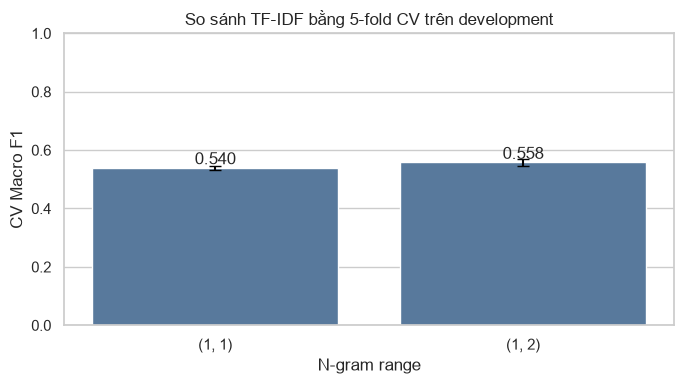

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from src.features import deduplicate_modeling_rows

modeling_df, duplicate_audit = deduplicate_modeling_rows(df)
development_idx, final_test_idx = train_test_split(
    modeling_df.index, test_size=0.2, random_state=2026,
    stratify=modeling_df['sentiment'],
)
development_df = modeling_df.loc[development_idx]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=2026)
candidate_ngram_ranges = [(1, 1), (1, 2)]
ngram_results = []
for ngram_range in candidate_ngram_ranges:
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=ngram_range, min_df=2, sublinear_tf=True)),
        ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=2026)),
    ])
    scores = cross_val_score(
        pipeline, development_df['clean_advance_text'].fillna(''),
        development_df['sentiment'], cv=cv, scoring='f1_macro', n_jobs=-1,
    )
    ngram_results.append({
        'ngram_range': str(ngram_range),
        'cv_macro_f1_mean': scores.mean(),
        'cv_macro_f1_std': scores.std(),
    })
ngram_results = pd.DataFrame(ngram_results)
selected_ngram = candidate_ngram_ranges[int(ngram_results['cv_macro_f1_mean'].idxmax())]
print(f'Cấu hình được chọn trên development CV: {selected_ngram}')
display(ngram_results.round(4))
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=ngram_results, x='ngram_range', y='cv_macro_f1_mean', color='#4C78A8', ax=ax)
ax.errorbar(range(len(ngram_results)), ngram_results['cv_macro_f1_mean'], yerr=ngram_results['cv_macro_f1_std'], fmt='none', color='black', capsize=4)
for patch, value in zip(ax.patches, ngram_results['cv_macro_f1_mean']):
    ax.annotate(f'{value:.3f}', (patch.get_x() + patch.get_width() / 2, value), ha='center', va='bottom')
ax.set(title='So sánh TF-IDF bằng 5-fold CV trên development', xlabel='N-gram range', ylabel='CV Macro F1', ylim=(0, 1))
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'eda_tfidf_ngram_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 7b. So sánh TF-IDF với Bag-of-Words

Hai phương pháp vector hóa được so sánh trên cùng bộ fold, cùng cấu hình từ vựng và cùng bộ phân loại.


In [11]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, recall_score

LABELS = ['Negative', 'Neutral', 'Positive']

def score_prediction(truth, pred):
    per_class_f1 = f1_score(truth, pred, average=None, labels=LABELS)
    per_class_recall = recall_score(truth, pred, average=None, labels=LABELS)
    return {
        'macro_f1': f1_score(truth, pred, average='macro'),
        'neutral_f1': per_class_f1[1],
        'negative_f1': per_class_f1[0],
        'negative_recall': per_class_recall[0],
        'accuracy': accuracy_score(truth, pred),
    }

def summarise(records, names, key='config'):
    rows = []
    for name in names:
        frame = pd.DataFrame(records[name])
        row = {key: name}
        for column in frame.columns:
            row[column] = frame[column].mean()
            row[f'{column}_std'] = frame[column].std(ddof=0)
        rows.append(row)
    return pd.DataFrame(rows)

vectorizer_options = dict(max_features=5000, ngram_range=selected_ngram, min_df=2)
vector_names = ['TF-IDF (sublinear)', 'Bag-of-Words']
vector_records = {name: [] for name in vector_names}

for train_pos, valid_pos in cv.split(development_df, development_df['sentiment']):
    fold_train = development_df.iloc[train_pos]
    fold_valid = development_df.iloc[valid_pos]
    builders = {
        'TF-IDF (sublinear)': TfidfVectorizer(**vectorizer_options, sublinear_tf=True),
        'Bag-of-Words': CountVectorizer(**vectorizer_options),
    }
    for name, vectorizer in builders.items():
        X_tr = vectorizer.fit_transform(fold_train['clean_advance_text'].fillna(''))
        X_va = vectorizer.transform(fold_valid['clean_advance_text'].fillna(''))
        model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=2026)
        model.fit(X_tr, fold_train['sentiment'])
        vector_records[name].append(score_prediction(fold_valid['sentiment'], model.predict(X_va)))

vector_results = summarise(vector_records, vector_names)
display(vector_results[['config', 'macro_f1', 'neutral_f1', 'negative_recall', 'negative_f1', 'accuracy']].round(4))
delta = pd.DataFrame(vector_records['Bag-of-Words'])['macro_f1'] - pd.DataFrame(vector_records['TF-IDF (sublinear)'])['macro_f1']
print(f'Bag-of-Words so với TF-IDF: {delta.mean():+.4f} Macro F1, thắng {int((delta > 0).sum())}/5 fold')
vector_results.to_csv(PROJECT_ROOT / 'reports' / 'tv2_vectorizer_comparison.csv', index=False)

,config,macro_f1,neutral_f1,negative_recall,negative_f1,accuracy
0,TF-IDF (sublinear),0.5579,0.4456,0.4563,0.3894,0.7158
1,Bag-of-Words,0.5418,0.4147,0.3773,0.3706,0.7177


Bag-of-Words so với TF-IDF: -0.0161 Macro F1, thắng 1/5 fold


## 8. Ablation: mô hình học từ text hay từ điểm số?

Năm nhóm đặc trưng được so sánh trên cùng bộ fold và cùng bộ phân loại. Chênh lệch được kiểm định theo từng cặp fold, vì độ lệch chuẩn giữa các fold có thể lớn hơn chính chênh lệch cần đo.


In [12]:
import sys as _sys
from scipy import sparse
from sklearn.preprocessing import MinMaxScaler
from src.features import ASPECT_RATING_FEATURES, LEXICON_FEATURES

_scripts = str(PROJECT_ROOT / 'scripts')
if _scripts not in _sys.path:
    _sys.path.insert(0, _scripts)
from plot_ablation_figures import plot_macro_f1, plot_per_class

group_names = ['Text-only', 'Text + lexicon', 'Text + aspect', 'Text + lexicon + aspect', 'Aspect ratings only']
ablation_records = {name: [] for name in group_names}

for fold_train_pos, fold_valid_pos in cv.split(development_df, development_df['sentiment']):
    fold_train = development_df.iloc[fold_train_pos]
    fold_valid = development_df.iloc[fold_valid_pos]
    vectorizer = TfidfVectorizer(max_features=5000, ngram_range=selected_ngram, min_df=2, sublinear_tf=True)
    X_text_train = vectorizer.fit_transform(fold_train['clean_advance_text'].fillna(''))
    X_text_valid = vectorizer.transform(fold_valid['clean_advance_text'].fillna(''))

    lex_scaler = MinMaxScaler()
    X_lex_train = sparse.csr_matrix(lex_scaler.fit_transform(fold_train[list(LEXICON_FEATURES)]))
    X_lex_valid = sparse.csr_matrix(lex_scaler.transform(fold_valid[list(LEXICON_FEATURES)]))
    aspect_scaler = MinMaxScaler()
    X_asp_train = sparse.csr_matrix(aspect_scaler.fit_transform(fold_train[list(ASPECT_RATING_FEATURES)]))
    X_asp_valid = sparse.csr_matrix(aspect_scaler.transform(fold_valid[list(ASPECT_RATING_FEATURES)]))

    feature_sets = {
        'Text-only': (X_text_train, X_text_valid),
        'Text + lexicon': (sparse.hstack([X_text_train, X_lex_train], format='csr'),
                           sparse.hstack([X_text_valid, X_lex_valid], format='csr')),
        'Text + aspect': (sparse.hstack([X_text_train, X_asp_train], format='csr'),
                          sparse.hstack([X_text_valid, X_asp_valid], format='csr')),
        'Text + lexicon + aspect': (sparse.hstack([X_text_train, X_lex_train, X_asp_train], format='csr'),
                                    sparse.hstack([X_text_valid, X_lex_valid, X_asp_valid], format='csr')),
        'Aspect ratings only': (X_asp_train, X_asp_valid),
    }
    for name, (X_fold_train, X_fold_valid) in feature_sets.items():
        model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=2026)
        model.fit(X_fold_train, fold_train['sentiment'])
        ablation_records[name].append(score_prediction(fold_valid['sentiment'], model.predict(X_fold_valid)))

ablation_results = summarise(ablation_records, group_names, key='feature_group')
display(ablation_results[['feature_group', 'macro_f1', 'neutral_f1', 'negative_recall', 'negative_f1', 'accuracy']].round(4))

baseline = pd.DataFrame(ablation_records['Text-only'])['macro_f1']
print('So sánh theo cặp fold với Text-only:')
for name in group_names[1:]:
    delta = pd.DataFrame(ablation_records[name])['macro_f1'] - baseline
    print(f'  {name:<24} {delta.mean():+.4f} Macro F1 | thắng {int((delta > 0).sum())}/5 fold | min {delta.min():+.4f}')

ablation_results.to_csv(PROJECT_ROOT / 'reports' / 'aspect_hybrid_ablation.csv', index=False)
plot_macro_f1(ablation_results)
plot_per_class(ablation_results)

,feature_group,macro_f1,neutral_f1,negative_recall,negative_f1,accuracy
0,Text-only,0.5579,0.4456,0.4563,0.3894,0.7158
1,Text + lexicon,0.5658,0.4508,0.4824,0.4049,0.7204
2,Text + aspect,0.7369,0.6441,0.6952,0.6485,0.8373
3,Text + lexicon + aspect,0.7389,0.6448,0.6995,0.6526,0.8389
4,Aspect ratings only,0.7388,0.6353,0.7676,0.6649,0.8337


So sánh theo cặp fold với Text-only:
  Text + lexicon           +0.0079 Macro F1 | thắng 3/5 fold | min -0.0021
  Text + aspect            +0.1789 Macro F1 | thắng 5/5 fold | min +0.1635
  Text + lexicon + aspect  +0.1809 Macro F1 | thắng 5/5 fold | min +0.1631
  Aspect ratings only      +0.1808 Macro F1 | thắng 5/5 fold | min +0.1640
Đã lưu: /Users/duyvu/Downloads/NLP-Sentiment-Analysis-ITviec/reports/figures/eda_feature_ablation_cv.png


Đã lưu: /Users/duyvu/Downloads/NLP-Sentiment-Analysis-ITviec/reports/figures/eda_ablation_per_class.png


## 9. Tạo artifact text-only và khóa final test

Artifact chính chỉ gồm TF-IDF text để khớp ứng dụng nhập văn bản. Final test dùng seed 2026, được khóa cho TV3 và không được TV2 dùng để chọn feature hay báo cáo điểm mô hình.

In [13]:
import hashlib
import importlib.metadata as package_metadata
import json
import platform
import subprocess

from src.features import FeatureExtractor, prepare_feature_split, save_feature_split

text_extractor = FeatureExtractor(
    method='tfidf', max_features=5000, ngram_range=selected_ngram,
    min_df=2, numeric_features=(),
)
split = prepare_feature_split(
    modeling_df, extractor=text_extractor, numeric_columns=(),
    test_size=0.2, random_state=2026,
)
assert set(split.test_indices) == set(final_test_idx)

vectorizer_path = MODELS_DIR / 'text_tfidf_vectorizer.joblib'
extractor_path = MODELS_DIR / 'text_feature_extractor.joblib'
split_path = MODELS_DIR / 'train_test_features.joblib'
manifest_path = MODELS_DIR / 'artifact_manifest.json'
text_extractor.save_vectorizer(vectorizer_path)
text_extractor.save_bundle(extractor_path)
artifact_metadata = {
    'feature_mode': 'text_only',
    'text_column': 'clean_advance_text',
    'label_column': 'sentiment',
    'split_seed': 2026,
    'test_size': 0.2,
    'ngram_range': list(selected_ngram),
    'max_features': 5000,
    'min_df': 2,
    'final_test_policy': 'locked_not_evaluated_by_tv2',
    'duplicate_audit': duplicate_audit,
}
save_feature_split(split, split_path, extractor=text_extractor, metadata=artifact_metadata)

def sha256_file(path):
    digest = hashlib.sha256()
    with path.open('rb') as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()

artifact_paths = [vectorizer_path, extractor_path, split_path]
manifest = {
    'schema_version': 1,
    'git_sha': subprocess.check_output(['git', 'rev-parse', 'HEAD'], cwd=PROJECT_ROOT, text=True).strip(),
    'git_branch': subprocess.check_output(['git', 'branch', '--show-current'], cwd=PROJECT_ROOT, text=True).strip(),
    'git_dirty': bool(subprocess.check_output(['git', 'status', '--porcelain'], cwd=PROJECT_ROOT, text=True).strip()),
    'data_file': str(DATA_PATH.relative_to(PROJECT_ROOT)),
    'data_sha256': sha256_file(DATA_PATH),
    'requirements_lock_sha256': sha256_file(PROJECT_ROOT / 'requirements.lock'),
    'source_rows': len(df),
    'modeling_rows': len(modeling_df),
    'train_rows': split.X_train.shape[0],
    'test_rows': split.X_test.shape[0],
    'feature_count': split.X_train.shape[1],
    'runtime': {
        'python': platform.python_version(),
        **{name: package_metadata.version(name) for name in ['numpy', 'pandas', 'scipy', 'scikit-learn', 'joblib']},
    },
    'feature_contract': artifact_metadata,
    'artifacts': {path.name: {'sha256': sha256_file(path), 'bytes': path.stat().st_size} for path in artifact_paths},
}
manifest_path.write_text(json.dumps(manifest, ensure_ascii=False, indent=2) + '\n', encoding='utf-8')
print(f'X_train: {split.X_train.shape}; X_test: {split.X_test.shape}')
print('Train:', split.y_train.value_counts().to_dict())
print('Final test đã khóa; TV2 không tính metric trên tập này.')
print(f'Manifest: {manifest_path}')

Đã lưu vectorizer tại: /Users/duyvu/Downloads/NLP-Sentiment-Analysis-ITviec/models/text_tfidf_vectorizer.joblib
Đã lưu feature extractor tại: /Users/duyvu/Downloads/NLP-Sentiment-Analysis-ITviec/models/text_feature_extractor.joblib
Đã lưu train/test features tại: /Users/duyvu/Downloads/NLP-Sentiment-Analysis-ITviec/models/train_test_features.joblib
X_train: (6730, 5000); X_test: (1683, 5000)
Train: {'Positive': 4964, 'Neutral': 1310, 'Negative': 456}
Final test đã khóa; TV2 không tính metric trên tập này.
Manifest: /Users/duyvu/Downloads/NLP-Sentiment-Analysis-ITviec/models/artifact_manifest.json


## 10. So sánh chiến lược cân bằng lớp

SMOTE chỉ áp dụng trên phần huấn luyện của từng fold, không bao giờ trên phần kiểm định, nhằm tránh mẫu tổng hợp rò rỉ sang dữ liệu đánh giá.


In [14]:
from src.features import apply_smote

X_train_smote, y_train_smote = apply_smote(split.X_train, split.y_train, random_state=2026)
smote_comparison = pd.DataFrame({
    'before': split.y_train.value_counts(),
    'after_smote': pd.Series(y_train_smote).value_counts(),
}).fillna(0).astype(int)
display(smote_comparison)
print(f'Ma trận sau SMOTE: {X_train_smote.shape}')

balance_names = ["class_weight='balanced'", 'SMOTE (không trọng số lớp)', 'Không xử lý']
balance_records = {name: [] for name in balance_names}

for train_pos, valid_pos in cv.split(development_df, development_df['sentiment']):
    fold_train = development_df.iloc[train_pos]
    fold_valid = development_df.iloc[valid_pos]
    vectorizer = TfidfVectorizer(max_features=5000, ngram_range=selected_ngram, min_df=2, sublinear_tf=True)
    X_tr = vectorizer.fit_transform(fold_train['clean_advance_text'].fillna(''))
    X_va = vectorizer.transform(fold_valid['clean_advance_text'].fillna(''))
    y_tr, y_va = fold_train['sentiment'], fold_valid['sentiment']

    for name in balance_names:
        if name == "class_weight='balanced'":
            model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=2026)
            model.fit(X_tr, y_tr)
        elif name == 'Không xử lý':
            model = LogisticRegression(max_iter=1000, random_state=2026)
            model.fit(X_tr, y_tr)
        else:
            X_res, y_res = apply_smote(X_tr, y_tr, random_state=2026)
            model = LogisticRegression(max_iter=1000, random_state=2026)
            model.fit(X_res, y_res)
        balance_records[name].append(score_prediction(y_va, model.predict(X_va)))

balance_results = summarise(balance_records, balance_names)
display(balance_results[['config', 'macro_f1', 'neutral_f1', 'negative_recall', 'negative_f1', 'accuracy']].round(4))
delta = pd.DataFrame(balance_records['SMOTE (không trọng số lớp)'])['macro_f1'] - pd.DataFrame(balance_records["class_weight='balanced'"])['macro_f1']
print(f'SMOTE so với class_weight: {delta.mean():+.4f} Macro F1, thắng {int((delta > 0).sum())}/5 fold')
balance_results.to_csv(PROJECT_ROOT / 'reports' / 'tv2_balancing_comparison.csv', index=False)

,before,after_smote
Negative,456,4964
Neutral,1310,4964
Positive,4964,4964


Ma trận sau SMOTE: (14892, 5000)


,config,macro_f1,neutral_f1,negative_recall,negative_f1,accuracy
0,class_weight='balanced',0.5579,0.4456,0.4563,0.3894,0.7158
1,SMOTE (không trọng số lớp),0.5600,0.4340,0.4410,0.3989,0.7263
2,Không xử lý,0.4622,0.3508,0.0921,0.1646,0.7676


SMOTE so với class_weight: +0.0020 Macro F1, thắng 2/5 fold


## Kết luận

- Biểu diễn văn bản dùng TF-IDF unigram kết hợp bigram, cao hơn Bag-of-Words 0,0161 Macro F1.
- Chiến lược cân bằng lớp dùng `class_weight='balanced'`, vì SMOTE chỉ cải thiện ở 2 trên 5 fold.
- Điểm khía cạnh cải thiện mạnh Neutral F1 và Recall Negative, nhưng tương quan cao với `Rating` sinh ra nhãn, nên chỉ dùng cho phần thực nghiệm.
- Cấu hình chỉ dùng văn bản phục vụ kịch bản dự đoán từ văn bản tự do.
- Toàn bộ biểu đồ lưu tại `reports/figures/`, số liệu lưu tại `reports/*.csv`, artifact lưu tại `models/`.
